# Steam Game Market Analysis - Database Edition

This notebook performs comprehensive analysis of Steam game market data using Postgres database operations.

**Features:**
- Memory-efficient database queries for large-scale data (50M+ reviews)
- Interactive visualizations and market insights
- Genre-based filtering and analysis
- User behavior and game popularity metrics
- Market concentration analysis

**Prerequisites:**
- Run the database assembler first: `cd graph-analyser/assemble-graph-database && make run`
- Ensure `steam_reviews.db` exists in the working directory or specify the path below

## Import Required Libraries

Import necessary libraries for database operations, data analysis, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
import os
import gc
from pathlib import Path
from typing import List, Dict, Tuple, Optional

# PostgreSQL imports
try:
    import psycopg2
    from sqlalchemy import create_engine, text
    print("✓ PostgreSQL drivers loaded successfully")
except ImportError as e:
    print("❌ PostgreSQL dependencies missing. Please install:")
    print("   pip install psycopg2-binary sqlalchemy")
    raise e
  
# Load environment variables from .env file
from dotenv import load_dotenv

env_file = Path("assemble-graph-database/.env")
if env_file.exists():
    load_dotenv(env_file)
    print(f"✓ Loaded environment variables from {env_file}")
else:
    print(f"⚠️  .env file not found at {env_file}")
    print("💡 Using default values")

# Configure display settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("✓ Libraries imported successfully")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ Numpy version: {np.__version__}")

output_dir = Path("analysis_plots")
output_dir.mkdir(exist_ok=True)

✓ PostgreSQL drivers loaded successfully
✓ Loaded environment variables from assemble-graph-database/.env
✓ Libraries imported successfully
✓ Pandas version: 2.3.2
✓ Numpy version: 2.3.2


## Database Connection Setup

Connect to the Steam reviews SQLite database and verify its structure.

In [2]:
# PostgreSQL Database connection configuration

# Database connection parameters
DB_HOST = os.getenv('DB_HOST', '127.0.0.1')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_USER = os.getenv('DB_USER', 'postgres')
DB_PASSWORD = os.getenv('DB_PASSWORD', 'postgres')
DB_NAME = os.getenv('DB_NAME', 'steam_reviews')
DB_SSLMODE = os.getenv('DB_SSLMODE', 'disable')

# PostgreSQL connection string
connection_string = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode={DB_SSLMODE}"

print(f"🐘 Connecting to PostgreSQL database:")
print(f"   Host: {DB_HOST}:{DB_PORT}")
print(f"   Database: {DB_NAME}")
print(f"   User: {DB_USER}")

# Connect to database
try:
    # Create SQLAlchemy engine for pandas integration
    engine = create_engine(connection_string)
    
    # Test connection with direct psycopg2
    conn = psycopg2.connect(
        host=DB_HOST,
        port=DB_PORT,
        user=DB_USER,
        password=DB_PASSWORD,
        database=DB_NAME
    )
    
    print(f"✓ Connected to PostgreSQL database: {DB_HOST}:{DB_PORT}/{DB_NAME}")
    
    # Get database size information
    cursor = conn.cursor()
    cursor.execute("""
        SELECT pg_size_pretty(pg_database_size(%s)) as db_size;
    """, (DB_NAME,))
    db_size = cursor.fetchone()[0]
    print(f"✓ Database size: {db_size}")
    cursor.close()
    
    # For pandas compatibility, we'll use the engine for pd.read_sql_query
    # Note: conn is psycopg2 connection, engine is SQLAlchemy engine
    
except Exception as e:
    print(f"❌ Database connection failed: {e}")
    print(f"💡 Make sure PostgreSQL is running and the database exists.")
    print(f"💡 Run: cd graph-analyser/assemble-graph-database && docker compose --env-file assemble-graph-database/.env up -d")
    raise

🐘 Connecting to PostgreSQL database:
   Host: 127.0.0.1:25432
   Database: steam_reviews
   User: postgres


✓ Connected to PostgreSQL database: 127.0.0.1:25432/steam_reviews
✓ Database size: 27 GB


## Correlation between centrality indicators and game success (nº of reviews)

Compute
- Degree centrality: identify popular games and very active players
- Harmonic centrality (in place of closeness since the graph isn't connected): identify ecletic players and popular games
- Betweenness centrality: identify players and games that connects different clusters
- Eigenvector centrality: identify "influential" games
- Cross-Clique centrality: identify "influential" games and players belonging to different groups
- Freeman Centralization: measure how centralized the network is on the most central game

#### Correlation between degree centrality and game success

Clearly, if we consider success a bigger number of reviews, than a game degree is correlated to the games review count with a correlation coefficient of 1.

### Freeman centralization using degree centrality

$C_x = \frac{\sum^{N}_{i=1} C_x(p_*) - C_x(p_i)}{\max \sum^{N}_{i=1} C_x(p_*) - C_x(p_i)}$

📊 Computing Freeman Centralization Metric

🎮 Computing Freeman Centralization for Games...


   Maximum game degree: 840,001
   Sum of differences: 82,353,847,075
   Number of game nodes: 98,101
   Theoretical maximum sum: 2,169,793,261,800
   Freeman Centralization (Games): 0.037955

👥 Computing Freeman Centralization for Users...
   Maximum user degree: 4,116
   Sum of differences: 90,987,329,622
   Number of user nodes: 22,118,178
   Theoretical maximum sum: 2,169,815,281,877
   Freeman Centralization (Users): 0.041933

📋 Freeman Centralization Summary:
------------------------------------------------------------
   Games:  0.037955
   Users:  0.041933

💡 Interpretation:
   - Values close to 0: Decentralized network (all nodes similar degree)
   - Values close to 1: Centralized network (star-like structure)

💾 Storing Freeman Centralization metrics in database...
✓ Freeman Centralization metrics stored in graph_statistics table

📊 Creating Freeman Centralization visualization...
   Maximum user degree: 4,116
   Sum of differences: 90,987,329,622
   Number of user nodes: 22,

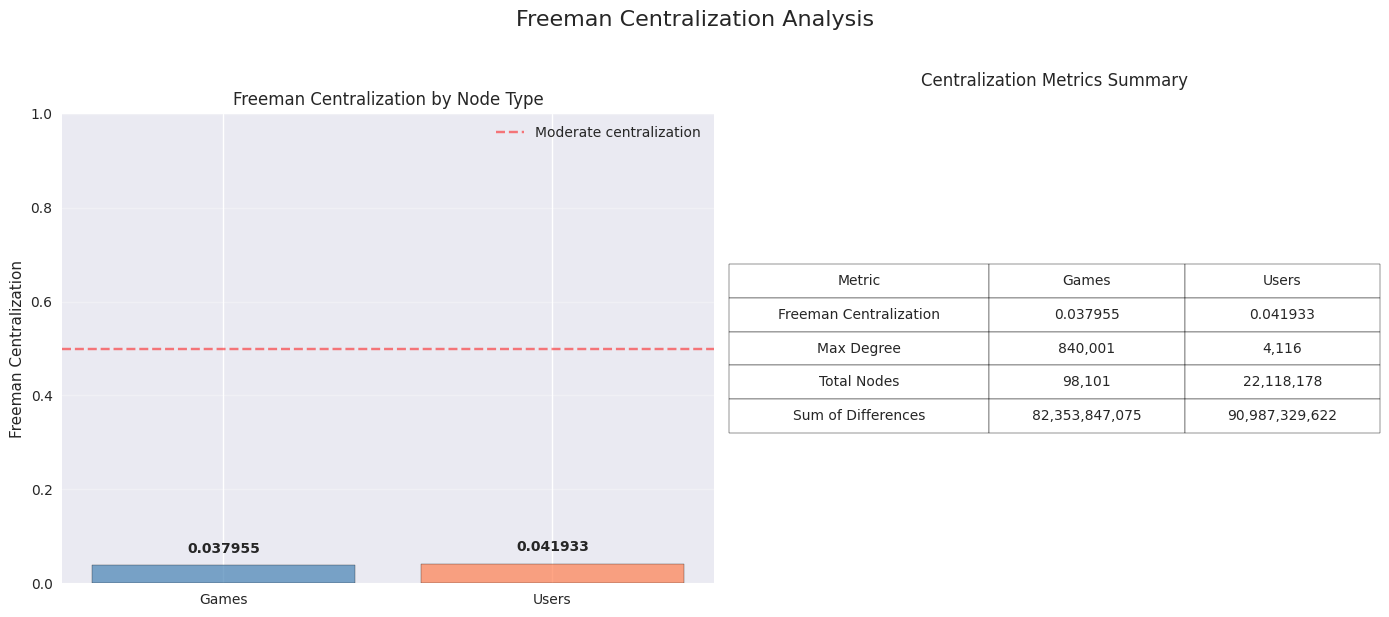

📊 Freeman Centralization plot saved to analysis_plots/freeman_centralization.png

✅ Freeman Centralization computation complete!


<Figure size 800x550 with 0 Axes>

In [7]:
# Freeman Centralization using Degree Centrality
print("📊 Computing Freeman Centralization Metric")
print("=" * 60)

# Freeman Centralization formula:
# C_x = Σ(C_x(p*) - C_x(p_i)) / max(Σ(C_x(p*) - C_x(p_i)))
# 
# Where:
# - C_x(p*) = maximum centrality (degree) in the network
# - C_x(p_i) = centrality (degree) of node i
# - Numerator = sum of differences from max degree
# - Denominator = theoretical maximum sum of differences (star network)

# Compute Freeman Centralization for Games
print("\n🎮 Computing Freeman Centralization for Games...")

# First get the max degree
max_degree_query = "SELECT MAX(degree) as max_degree, COUNT(*) as total_nodes FROM games"
max_degree_data = pd.read_sql_query(max_degree_query, engine)
max_degree_games = max_degree_data['max_degree'].iloc[0]
n_games = max_degree_data['total_nodes'].iloc[0]

# Then compute sum of differences using the max degree
sum_diff_query = f"""
SELECT SUM({max_degree_games} - degree) as sum_differences
FROM games
"""
sum_diff_data = pd.read_sql_query(sum_diff_query, engine)
sum_diff_games = sum_diff_data['sum_differences'].iloc[0]

# For a bipartite graph, the maximum possible degree for a game node is the number of users
n_users_query = "SELECT COUNT(*) as count FROM users"
n_users = pd.read_sql_query(n_users_query, engine)['count'].iloc[0]

# Theoretical maximum: star network where one node connects to all users
# and all other nodes have degree 0
max_sum_diff_games = (n_games - 1) * n_users

# Freeman Centralization for games
freeman_centralization_games = sum_diff_games / max_sum_diff_games if max_sum_diff_games > 0 else 0

print(f"   Maximum game degree: {max_degree_games:,}")
print(f"   Sum of differences: {sum_diff_games:,}")
print(f"   Number of game nodes: {n_games:,}")
print(f"   Theoretical maximum sum: {max_sum_diff_games:,}")
print(f"   Freeman Centralization (Games): {freeman_centralization_games:.6f}")

# Compute Freeman Centralization for Users
print("\n👥 Computing Freeman Centralization for Users...")

# First get the max degree
max_degree_user_query = "SELECT MAX(degree) as max_degree, COUNT(*) as total_nodes FROM users"
max_degree_user_data = pd.read_sql_query(max_degree_user_query, engine)
max_degree_users = max_degree_user_data['max_degree'].iloc[0]
n_users_actual = max_degree_user_data['total_nodes'].iloc[0]

# Then compute sum of differences using the max degree
sum_diff_user_query = f"""
SELECT SUM({max_degree_users} - degree) as sum_differences
FROM users
"""
sum_diff_user_data = pd.read_sql_query(sum_diff_user_query, engine)
sum_diff_users = sum_diff_user_data['sum_differences'].iloc[0]

# For a bipartite graph, the maximum possible degree for a user node is the number of games
n_games_query = "SELECT COUNT(*) as count FROM games"
n_games_actual = pd.read_sql_query(n_games_query, engine)['count'].iloc[0]

# Theoretical maximum: star network where one user connects to all games
# and all other users have degree 0
max_sum_diff_users = (n_users_actual - 1) * n_games_actual

# Freeman Centralization for users
freeman_centralization_users = sum_diff_users / max_sum_diff_users if max_sum_diff_users > 0 else 0

print(f"   Maximum user degree: {max_degree_users:,}")
print(f"   Sum of differences: {sum_diff_users:,}")
print(f"   Number of user nodes: {n_users_actual:,}")
print(f"   Theoretical maximum sum: {max_sum_diff_users:,}")
print(f"   Freeman Centralization (Users): {freeman_centralization_users:.6f}")

# Summary
print("\n📋 Freeman Centralization Summary:")
print("-" * 60)
print(f"   Games:  {freeman_centralization_games:.6f}")
print(f"   Users:  {freeman_centralization_users:.6f}")
print("\n💡 Interpretation:")
print("   - Values close to 0: Decentralized network (all nodes similar degree)")
print("   - Values close to 1: Centralized network (star-like structure)")

# Store Freeman Centralization metrics in database
print("\n💾 Storing Freeman Centralization metrics in database...")

freeman_stats = [
    {
        'name': 'freeman_centralization_games',
        'value': float(freeman_centralization_games),
        'type': 'centralization_metric',
        'description': 'Freeman Centralization for game nodes using degree centrality'
    },
    {
        'name': 'freeman_centralization_users',
        'value': float(freeman_centralization_users),
        'type': 'centralization_metric',
        'description': 'Freeman Centralization for user nodes using degree centrality'
    },
    {
        'name': 'max_degree_games',
        'value': float(max_degree_games),
        'type': 'centralization_metric',
        'description': 'Maximum degree among game nodes'
    },
    {
        'name': 'max_degree_users',
        'value': float(max_degree_users),
        'type': 'centralization_metric',
        'description': 'Maximum degree among user nodes'
    }
]

with engine.begin() as connection:
    for stat in freeman_stats:
        upsert_query = """
        INSERT INTO graph_statistics (statistic_name, statistic_value, statistic_type, description, updated_at)
        VALUES (:name, :value, :type, :description, CURRENT_TIMESTAMP)
        ON CONFLICT (statistic_name) 
        DO UPDATE SET 
            statistic_value = EXCLUDED.statistic_value,
            statistic_type = EXCLUDED.statistic_type,
            description = EXCLUDED.description,
            updated_at = CURRENT_TIMESTAMP
        """
        connection.execute(text(upsert_query), stat)

print("✓ Freeman Centralization metrics stored in graph_statistics table")

# Create visualization
print("\n📊 Creating Freeman Centralization visualization...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Freeman Centralization Analysis', fontsize=16, y=1.02)

# Bar chart comparing centralization
metrics = ['Games', 'Users']
values = [freeman_centralization_games, freeman_centralization_users]
colors_bar = ['steelblue', 'coral']

ax1.bar(metrics, values, color=colors_bar, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Freeman Centralization')
ax1.set_title('Freeman Centralization by Node Type')
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Moderate centralization')
ax1.legend()

# Add values on bars
for i, v in enumerate(values):
    ax1.text(i, v + 0.02, f'{v:.6f}', ha='center', va='bottom', fontweight='bold')

# Summary table
summary_data = [
    ['Metric', 'Games', 'Users'],
    ['Freeman Centralization', f'{freeman_centralization_games:.6f}', f'{freeman_centralization_users:.6f}'],
    ['Max Degree', f'{max_degree_games:,}', f'{max_degree_users:,}'],
    ['Total Nodes', f'{n_games:,}', f'{n_users_actual:,}'],
    ['Sum of Differences', f'{sum_diff_games:,}', f'{sum_diff_users:,}']
]

ax2.axis('tight')
ax2.axis('off')
table = ax2.table(cellText=summary_data[1:], colLabels=summary_data[0],
                  cellLoc='center', loc='center',
                  colWidths=[0.4, 0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
ax2.set_title('Centralization Metrics Summary', pad=20)

plt.tight_layout()
plt.show()

# Save plot
plt.savefig(output_dir / 'freeman_centralization.png', dpi=300, bbox_inches='tight')
print(f"📊 Freeman Centralization plot saved to {output_dir / 'freeman_centralization.png'}")

print("\n✅ Freeman Centralization computation complete!")

## One-Mode Projection: Game-to-Game Network

Create a projection of the bipartite graph where:
- **Nodes**: Only games (removing users)
- **Edges**: Connect two games if they share at least one player/reviewer
- **Edge Weight**: Number of players who reviewed both games (shared audience strength)

This projection reveals game similarity and market overlap based on player behavior.

### Create Projection Table

Create a table to store the one-mode projection edges with weights.

In [3]:
# Create table for one-mode projection
print("🔧 Creating game_projection_edges table...")
print("=" * 60)

create_projection_table = """
CREATE TABLE IF NOT EXISTS game_projection_edges (
    id SERIAL PRIMARY KEY,
    game_id_1 VARCHAR(255) NOT NULL,
    game_id_2 VARCHAR(255) NOT NULL,
    weight INTEGER NOT NULL,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    CONSTRAINT game_projection_unique UNIQUE (game_id_1, game_id_2),
    CONSTRAINT game_projection_ordered CHECK (game_id_1 < game_id_2),
    FOREIGN KEY (game_id_1) REFERENCES games(game_id) ON DELETE CASCADE,
    FOREIGN KEY (game_id_2) REFERENCES games(game_id) ON DELETE CASCADE
);
"""

with engine.begin() as connection:
    connection.execute(text(create_projection_table))

print("✓ game_projection_edges table created (if not existed)")

# Create indexes for better query performance
print("\n🔧 Creating indexes on projection table...")

create_indexes = [
    "CREATE INDEX IF NOT EXISTS idx_game_proj_game1 ON game_projection_edges(game_id_1);",
    "CREATE INDEX IF NOT EXISTS idx_game_proj_game2 ON game_projection_edges(game_id_2);",
    "CREATE INDEX IF NOT EXISTS idx_game_proj_weight ON game_projection_edges(weight DESC);"
]

with engine.begin() as connection:
    for idx_query in create_indexes:
        connection.execute(text(idx_query))

print("✓ Indexes created successfully")

# Check if table already has data
check_data_query = "SELECT COUNT(*) as count FROM game_projection_edges"
existing_edges = pd.read_sql_query(check_data_query, engine)['count'].iloc[0]

if existing_edges > 0:
    print(f"\n⚠️  Table already contains {existing_edges:,} edges")
    print("💡 To recompute, truncate the table first:")
    print("   TRUNCATE TABLE game_projection_edges;")
else:
    print("\n✓ Table is empty and ready for data")

print("\n✅ Projection table setup complete!")

🔧 Creating game_projection_edges table...
✓ game_projection_edges table created (if not existed)

🔧 Creating indexes on projection table...
✓ Indexes created successfully

✓ Table is empty and ready for data

✅ Projection table setup complete!


### Compute One-Mode Projection

Compute the game-to-game edges by finding all pairs of games that share at least one player.

**Algorithm**: For each player, find all pairs of games they reviewed and count shared players.

**Note**: This operation can be computationally intensive for large datasets.

In [ ]:
# Compute one-mode projection
print("📊 Computing One-Mode Projection (Game-to-Game Network)")
print("=" * 60)

# Check if we need to compute
check_data_query = "SELECT COUNT(*) as count FROM game_projection_edges"
existing_edges = pd.read_sql_query(check_data_query, engine)['count'].iloc[0]

if existing_edges > 0:
    print(f"✓ Projection already computed with {existing_edges:,} edges")
    print("💡 Skipping computation. To recompute, truncate the table first.")
else:
    print("⏳ Computing projection... This may take several minutes for large datasets")
    print("💡 Finding all game pairs that share at least one player...")
    
    # Insert projection edges using a single SQL query
    # This query finds all pairs of games reviewed by the same user
    # and counts how many users reviewed both games
    insert_projection_query = """
    INSERT INTO game_projection_edges (game_id_1, game_id_2, weight)
    SELECT 
        LEAST(r1.game_id, r2.game_id) as game_id_1,
        GREATEST(r1.game_id, r2.game_id) as game_id_2,
        COUNT(*) as weight
    FROM reviews r1
    INNER JOIN reviews r2 ON r1.user_id = r2.user_id AND r1.game_id < r2.game_id
    GROUP BY LEAST(r1.game_id, r2.game_id), GREATEST(r1.game_id, r2.game_id)
    ON CONFLICT (game_id_1, game_id_2) DO NOTHING;
    """
    
    print("\n🔄 Executing projection query...")
    print("   This creates edges between games that share players...")
    
    with engine.begin() as connection:
        result = connection.execute(text(insert_projection_query))
        rows_inserted = result.rowcount if hasattr(result, 'rowcount') else 0
    
    print(f"✓ Projection computed successfully!")
    print(f"   Inserted {rows_inserted:,} edges")

print("\n✅ One-mode projection computation complete!")

📊 Computing One-Mode Projection (Game-to-Game Network)
⏳ Computing projection... This may take several minutes for large datasets
💡 Finding all game pairs that share at least one player...

🔄 Executing projection query...
   This creates edges between games that share players...


### Add Projection Degree Column

Add a column to store the degree of each game in the projected graph and populate it with the count of edges.

In [3]:
# Add projection degree column to games table
print("🔧 Adding projection_degree and projection_weighted_degree columns to games table...")
print("=" * 60)

# Add columns if they don't exist
add_columns_query = """
ALTER TABLE games 
ADD COLUMN IF NOT EXISTS projection_degree INTEGER DEFAULT 0,
ADD COLUMN IF NOT EXISTS projection_weighted_degree INTEGER DEFAULT 0;
"""

with engine.begin() as connection:
    connection.execute(text(add_columns_query))

print("✓ projection_degree column added (if not existed)")
print("✓ projection_weighted_degree column added (if not existed)")

# Populate projection_degree and projection_weighted_degree for all games
print("\n⏳ Computing projection metrics for all games...")
print("💡 Counting edges and summing weights in the projected graph for each game...")

# Update both degree and weighted degree in a single query for efficiency
# Since edges are stored with game_id_1 < game_id_2, we need to count both directions
update_metrics_query = """
UPDATE games g
SET 
    projection_degree = COALESCE(
        (SELECT COUNT(*) 
         FROM game_projection_edges e 
         WHERE e.game_id_1 = g.game_id OR e.game_id_2 = g.game_id),
        0
    ),
    projection_weighted_degree = COALESCE(
        (SELECT SUM(weight) 
         FROM game_projection_edges e 
         WHERE e.game_id_1 = g.game_id OR e.game_id_2 = g.game_id),
        0
    );
"""

with engine.begin() as connection:
    result = connection.execute(text(update_metrics_query))
    print(f"✓ Updated projection_degree for all games")
    print(f"✓ Updated projection_weighted_degree for all games")

# Get statistics about projection degrees
print("\n📊 Projection Degree Statistics:")
print("-" * 60)

stats_query = """
SELECT 
    COUNT(*) as total_games,
    COUNT(CASE WHEN projection_degree > 0 THEN 1 END) as connected_games,
    COUNT(CASE WHEN projection_degree = 0 THEN 1 END) as isolated_games,
    MIN(projection_degree) as min_degree,
    MAX(projection_degree) as max_degree,
    ROUND(AVG(projection_degree)::numeric, 2) as avg_degree,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY projection_degree) as median_degree,
    MIN(projection_weighted_degree) as min_weighted_degree,
    MAX(projection_weighted_degree) as max_weighted_degree,
    ROUND(AVG(projection_weighted_degree)::numeric, 2) as avg_weighted_degree,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY projection_weighted_degree) as median_weighted_degree
FROM games;
"""

stats_df = pd.read_sql_query(stats_query, engine)

print(f"   Total games: {stats_df['total_games'].iloc[0]:,}")
print(f"   Connected games: {stats_df['connected_games'].iloc[0]:,}")
print(f"   Isolated games: {stats_df['isolated_games'].iloc[0]:,}")
print(f"\n   Degree (unweighted):")
print(f"   - Min: {stats_df['min_degree'].iloc[0]:,}")
print(f"   - Max: {stats_df['max_degree'].iloc[0]:,}")
print(f"   - Average: {stats_df['avg_degree'].iloc[0]:,}")
print(f"   - Median: {stats_df['median_degree'].iloc[0]:,}")
print(f"\n   Weighted Degree (sum of edge weights):")
print(f"   - Min: {stats_df['min_weighted_degree'].iloc[0]:,}")
print(f"   - Max: {stats_df['max_weighted_degree'].iloc[0]:,}")
print(f"   - Average: {stats_df['avg_weighted_degree'].iloc[0]:,}")
print(f"   - Median: {stats_df['median_weighted_degree'].iloc[0]:,}")

# Show top games by projection degree
print("\n🏆 Top 10 Games by Projection Degree:")
print("-" * 60)

top_games_query = """
SELECT 
    game_id,
    name,
    projection_degree,
    projection_weighted_degree,
    degree as bipartite_degree
FROM games
WHERE projection_degree > 0
ORDER BY projection_degree DESC
LIMIT 10;
"""

top_games_df = pd.read_sql_query(top_games_query, engine)
print(top_games_df.to_string(index=False))

# Show top games by projection weighted degree
print("\n🏆 Top 10 Games by Projection Weighted Degree:")
print("-" * 60)

top_weighted_games_query = """
SELECT 
    game_id,
    name,
    projection_weighted_degree,
    projection_degree,
    degree as bipartite_degree
FROM games
WHERE projection_weighted_degree > 0
ORDER BY projection_weighted_degree DESC
LIMIT 10;
"""

top_weighted_games_df = pd.read_sql_query(top_weighted_games_query, engine)
print(top_weighted_games_df.to_string(index=False))

# Create index for better query performance
print("\n🔧 Creating indexes on projection metrics...")
create_indexes_query = """
CREATE INDEX IF NOT EXISTS idx_games_projection_degree 
ON games(projection_degree DESC);

CREATE INDEX IF NOT EXISTS idx_games_projection_weighted_degree 
ON games(projection_weighted_degree DESC);
"""

with engine.begin() as connection:
    connection.execute(text(create_indexes_query))

print("✓ Indexes created successfully")

print("\n✅ Projection degree computation complete!")


🔧 Adding projection_degree and projection_weighted_degree columns to games table...
✓ projection_degree column added (if not existed)
✓ projection_weighted_degree column added (if not existed)

⏳ Computing projection metrics for all games...
💡 Counting edges and summing weights in the projected graph for each game...
✓ Updated projection_degree for all games
✓ Updated projection_weighted_degree for all games

📊 Projection Degree Statistics:
------------------------------------------------------------
   Total games: 98,101
   Connected games: 32,244
   Isolated games: 65,857

   Degree (unweighted):
   - Min: 0
   - Max: 21,531
   - Average: 1,019.31
   - Median: 0.0

   Weighted Degree (sum of edge weights):
   - Min: 0
   - Max: 3,967,253
   - Average: 6,691.3
   - Median: 0.0

🏆 Top 10 Games by Projection Degree:
------------------------------------------------------------
game_id                        name  projection_degree  projection_weighted_degree  bipartite_degree
1086940   

### Compute Centrality Metrics for Projected Graph

Compute harmonic centrality and betweenness centrality for games in the projected graph using NetworkX.

**Harmonic Centrality**: Measures how close a game is to all other games (using reciprocal distances). Better than closeness centrality for disconnected graphs.

**Betweenness Centrality**: Measures how often a game appears on shortest paths between other games. Identifies "bridge" games that connect different clusters.

In [ ]:
# Import NetworkX for graph analysis
import networkx as nx
print("✓ NetworkX imported successfully")
print(f"✓ NetworkX version: {nx.__version__}")

# Add columns for centrality metrics
print("\n🔧 Adding centrality metric columns to games table...")
print("=" * 60)

add_centrality_columns_query = """
ALTER TABLE games 
ADD COLUMN IF NOT EXISTS projection_harmonic_centrality FLOAT,
ADD COLUMN IF NOT EXISTS projection_betweenness_centrality FLOAT;
"""

with engine.begin() as connection:
    connection.execute(text(add_centrality_columns_query))

print("✓ projection_harmonic_centrality column added (if not existed)")
print("✓ projection_betweenness_centrality column added (if not existed)")

# Load projection graph into NetworkX
print("\n⏳ Loading projection graph into NetworkX...")
print("💡 This may take a moment for large graphs...")

# Create NetworkX graph
G = nx.Graph()

# First, add all game nodes (including isolated ones)
print("\n📋 Adding all game nodes to the graph...")
nodes_query = "SELECT game_id FROM games"
nodes_df = pd.read_sql_query(nodes_query, engine)
G.add_nodes_from(nodes_df['game_id'])
print(f"✓ Added {len(nodes_df):,} game nodes to the graph")

# Then, fetch and add all edges from the projection table in batches
print("\n🔗 Adding edges from projection table in batches...")

# Get total number of edges
count_query = "SELECT COUNT(*) as count FROM game_projection_edges"
total_edges = pd.read_sql_query(count_query, engine)['count'].iloc[0]
print(f"   Total edges to process: {total_edges:,}")

# Process edges in batches to avoid memory issues
batch_size = 10000000  # Process 10M edges at a time
offset = 0
edges_added = 0

while offset < total_edges:
    print(f"   Processing batch {offset:,} to {min(offset + batch_size, total_edges):,}...", end=" ")
    
    # Fetch batch of edges
    batch_query = f"""
    SELECT game_id_1, game_id_2, weight 
    FROM game_projection_edges 
    ORDER BY id
    LIMIT {batch_size} OFFSET {offset}
    """
    edges_batch = pd.read_sql_query(batch_query, engine)
    
    # Add edges from this batch
    for _, row in edges_batch.iterrows():
        G.add_edge(row['game_id_1'], row['game_id_2'], weight=row['weight'])
        edges_added += 1
    
    print(f"✓ ({edges_added:,} total)")
    
    # Free memory after each batch
    del edges_batch
    gc.collect()
    
    offset += batch_size

print(f"✓ Added all {edges_added:,} edges to the graph")

print(f"\n✓ Created NetworkX graph")
print(f"   Total nodes: {G.number_of_nodes():,}")
print(f"   Nodes with edges: {G.number_of_nodes() - nx.number_of_isolates(G):,}")
print(f"   Isolated nodes: {nx.number_of_isolates(G):,}")
print(f"   Edges: {G.number_of_edges():,}")
print(f"   Connected components: {nx.number_connected_components(G):,}")

✓ NetworkX imported successfully
✓ NetworkX version: 3.5

🔧 Adding centrality metric columns to games table...
✓ projection_harmonic_centrality column added (if not existed)
✓ projection_betweenness_centrality column added (if not existed)

⏳ Loading projection graph into NetworkX...
💡 This may take a moment for large graphs...

📋 Adding all game nodes to the graph...
✓ Added 98,101 game nodes to the graph

🔗 Adding edges from projection table in batches...
   Total edges to process: 49,997,708
   Processing batch 0 to 10,000,000... ✓ (10,000,000 total)
   Processing batch 10,000,000 to 20,000,000... ✓ (20,000,000 total)
   Processing batch 20,000,000 to 30,000,000... ✓ (30,000,000 total)
   Processing batch 30,000,000 to 40,000,000... ✓ (40,000,000 total)
   Processing batch 40,000,000 to 49,997,708... ✓ (49,997,708 total)
✓ Added all 49,997,708 edges to the graph

✓ Created NetworkX graph
   Total nodes: 98,101
   Nodes with edges: 32,244
   Isolated nodes: 65,857
   Edges: 49,997,70

In [5]:
# Get the largest connected component for analysis
if nx.number_connected_components(G) > 1:
    print("\n⚠️  Graph has multiple components")
    largest_cc = max(nx.connected_components(G), key=len)
    print(f"   Largest component size: {len(largest_cc):,} nodes")
    G_main = G.subgraph(largest_cc)
    print(f"💡 Using largest component for centrality computation")
else:
    G_main = G
    print("✓ Graph is connected")

print("\n✅ Graph loaded successfully!")
gc.collect()


⚠️  Graph has multiple components
   Largest component size: 32,220 nodes
💡 Using largest component for centrality computation

✅ Graph loaded successfully!


46

#### Compute Harmonic Centrality

Harmonic centrality is computed as the sum of reciprocal distances to all other nodes. It works well for disconnected graphs.

In [ ]:
gc.collect()

import random

# Sample
sample_size = 100
print(f"💡 Sampling {sample_size:,} nodes for harmonic centrality computation...")
sampled_nodes = random.sample(list(G.nodes()), sample_size)

# Compute Harmonic Centrality
print("📊 Computing Harmonic Centrality for all games...")
print("=" * 60)
print("⏳ This may take several minutes for large graphs...")

harmonic_centrality = nx.harmonic_centrality(G, sources=sampled_nodes)

print(f"✓ Computed harmonic centrality for {len(harmonic_centrality):,} games")

# Convert to DataFrame for database insertion
harmonic_df = pd.DataFrame([
    {'game_id': game_id, 'harmonic_centrality': centrality}
    for game_id, centrality in harmonic_centrality.items()
])

# Get statistics
print("\n📊 Harmonic Centrality Statistics:")
print("-" * 60)
print(f"   Min: {harmonic_df['harmonic_centrality'].min():.6f}")
print(f"   Max: {harmonic_df['harmonic_centrality'].max():.6f}")
print(f"   Mean: {harmonic_df['harmonic_centrality'].mean():.6f}")
print(f"   Median: {harmonic_df['harmonic_centrality'].median():.6f}")
print(f"   Std Dev: {harmonic_df['harmonic_centrality'].std():.6f}")

💡 Sampling 100 nodes for harmonic centrality computation...
📊 Computing Harmonic Centrality for all games...
⏳ This may take several minutes for large graphs...
✓ Computed harmonic centrality for 98,101 games

📊 Harmonic Centrality Statistics:
------------------------------------------------------------
   Min: 0.000000
   Max: 27.000000
   Mean: 5.427850
   Median: 0.000000
   Std Dev: 7.878250


In [19]:
# Update database with harmonic centrality values
print("\n💾 Storing harmonic centrality values in database...")

# Create a temporary table for efficient bulk update
with engine.begin() as connection:
    connection.execute(text("""
        UPDATE games g
        SET projection_harmonic_centrality = NULL
    """))

    # Create temporary table
    connection.execute(text("""
        CREATE TEMP TABLE temp_harmonic_centrality (
            game_id VARCHAR(255) PRIMARY KEY,
            harmonic_centrality FLOAT
        )
    """))

    # Insert data into temporary table
    harmonic_df.to_sql('temp_harmonic_centrality', connection,
                       if_exists='append', index=False)

    # Update main table from temporary table
    connection.execute(text("""
        UPDATE games g
        SET projection_harmonic_centrality = t.harmonic_centrality
        FROM temp_harmonic_centrality t
        WHERE g.game_id = t.game_id
    """))

    # Drop temporary table
    connection.execute(text("DROP TABLE temp_harmonic_centrality"))

print(f"✓ Updated {len(harmonic_df):,} games with harmonic centrality values")

# Show top games by harmonic centrality
print("\n🏆 Top 10 Games by Harmonic Centrality:")
print("-" * 60)

top_harmonic_query = """
SELECT 
    game_id,
    name,
    projection_harmonic_centrality,
    projection_degree,
    projection_weighted_degree
FROM games
WHERE projection_harmonic_centrality > 0
ORDER BY projection_harmonic_centrality DESC
LIMIT 10;
"""

top_harmonic_df = pd.read_sql_query(top_harmonic_query, engine)
print(top_harmonic_df.to_string(index=False))

print("\n✅ Harmonic centrality computation complete!")


💾 Storing harmonic centrality values in database...
✓ Updated 98,101 games with harmonic centrality values

🏆 Top 10 Games by Harmonic Centrality:
------------------------------------------------------------
game_id                  name  projection_harmonic_centrality  projection_degree  projection_weighted_degree
 242760            The Forest                            27.0              20250                     2633137
1086940       Baldur's Gate 3                            27.0              21531                     3207897
 251570         7 Days to Die                            26.5              16180                      726691
 264710            Subnautica                            26.5              19054                     1668987
 108710             Alan Wake                            26.5              18729                     1060497
 214490      Alien: Isolation                            26.0              16895                      896449
1237970          Titanfall® 

#### Correlation between Harmonic Centrality and Bipartite Degree

Analyze the correlation between harmonic centrality in the projected graph and the degree in the original bipartite graph.

📊 Computing Correlation: Harmonic Centrality vs Bipartite Degree
✓ Loaded 98,101 games with harmonic centrality computed

📈 Correlation Statistics:
------------------------------------------------------------
   Pearson Correlation:  0.130872 (p-value: 0.00e+00)
   Spearman Correlation: 0.982682 (p-value: 0.00e+00)
   ✓ Correlation is statistically significant (p < 0.001)

💡 Interpretation:
   There is a very weak positive correlation between bipartite degree
   and harmonic centrality in the projected graph.

📊 Creating correlation visualization...
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
✓ Loaded 98,101 games with harmonic centrality computed

📈 C

LinAlgError: SVD did not converge in Linear Least Squares

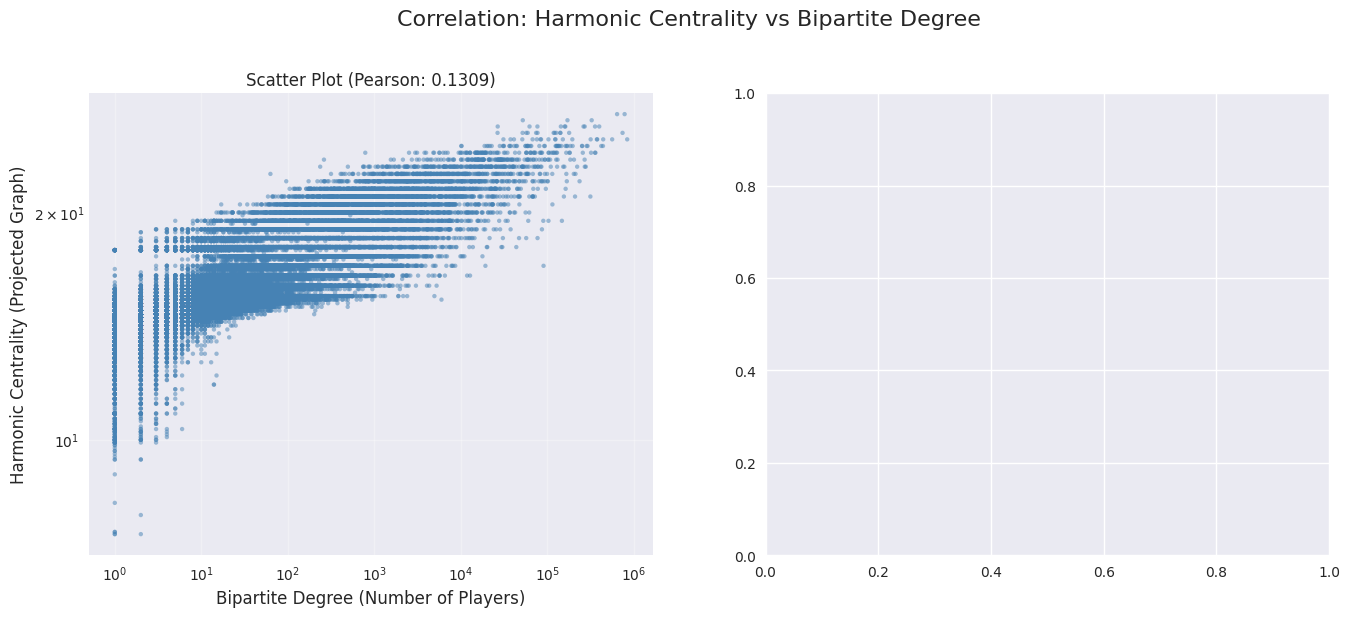

In [ ]:
# Compute correlation between Harmonic Centrality and Bipartite Degree
print("📊 Computing Correlation: Harmonic Centrality vs Bipartite Degree")
print("=" * 60)

# Query to get games with harmonic centrality computed
correlation_query = """
SELECT 
    game_id,
    name,
    degree as bipartite_degree,
    projection_harmonic_centrality
FROM games
WHERE projection_harmonic_centrality IS NOT NULL
ORDER BY projection_harmonic_centrality DESC;
"""

correlation_df = pd.read_sql_query(correlation_query, engine)

print(f"✓ Loaded {len(correlation_df):,} games with harmonic centrality computed")

# Compute Pearson correlation coefficient
from scipy.stats import pearsonr, spearmanr

pearson_corr, pearson_pvalue = pearsonr(
    correlation_df['bipartite_degree'], 
    correlation_df['projection_harmonic_centrality']
)

spearman_corr, spearman_pvalue = spearmanr(
    correlation_df['bipartite_degree'], 
    correlation_df['projection_harmonic_centrality']
)

print(f"\n📈 Correlation Statistics:")
print("-" * 60)
print(f"   Pearson Correlation:  {pearson_corr:.6f} (p-value: {pearson_pvalue:.2e})")
print(f"   Spearman Correlation: {spearman_corr:.6f} (p-value: {spearman_pvalue:.2e})")

if pearson_pvalue < 0.001:
    print("   ✓ Correlation is statistically significant (p < 0.001)")
elif pearson_pvalue < 0.05:
    print("   ✓ Correlation is statistically significant (p < 0.05)")
else:
    print("   ⚠️  Correlation is not statistically significant")

# Interpretation
print("\n💡 Interpretation:")
if abs(pearson_corr) > 0.7:
    strength = "strong"
elif abs(pearson_corr) > 0.4:
    strength = "moderate"
elif abs(pearson_corr) > 0.2:
    strength = "weak"
else:
    strength = "very weak"

direction = "positive" if pearson_corr > 0 else "negative"
print(f"   There is a {strength} {direction} correlation between bipartite degree")
print(f"   and harmonic centrality in the projected graph.")

# Create visualization
print("\n📊 Creating correlation visualization...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation: Harmonic Centrality vs Bipartite Degree', fontsize=16, y=1.02)

# Scatter plot
ax1 = axes[0]
ax1.scatter(
    correlation_df['bipartite_degree'], 
    correlation_df['projection_harmonic_centrality'],
    alpha=0.5,
    s=10,
    c='steelblue',
    edgecolors='none'
)
ax1.set_xlabel('Bipartite Degree (Number of Players)', fontsize=12)
ax1.set_ylabel('Harmonic Centrality (Projected Graph)', fontsize=12)
ax1.set_title(f'Scatter Plot (Pearson: {pearson_corr:.4f})', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

# Add trend line with error handling
try:
    # Filter out any potential zeros or NaN values for log transformation
    valid_mask = (correlation_df['bipartite_degree'] > 0) & \
                 (correlation_df['projection_harmonic_centrality'] > 0) & \
                 np.isfinite(correlation_df['bipartite_degree']) & \
                 np.isfinite(correlation_df['projection_harmonic_centrality'])
    
    if valid_mask.sum() > 10:  # Need at least 10 points for a meaningful fit
        valid_x = correlation_df.loc[valid_mask, 'bipartite_degree']
        valid_y = correlation_df.loc[valid_mask, 'projection_harmonic_centrality']
        
        # Fit polynomial in log space
        z = np.polyfit(np.log10(valid_x), np.log10(valid_y), 1)
        p = np.poly1d(z)
        
        # Generate trend line
        x_trend = np.logspace(
            np.log10(valid_x.min()),
            np.log10(valid_x.max()),
            100
        )
        y_trend = 10 ** p(np.log10(x_trend))
        ax1.plot(x_trend, y_trend, "r--", alpha=0.8, linewidth=2, label='Trend line')
        ax1.legend()
    else:
        print("   ⚠️  Not enough valid data points for trend line")
except Exception as e:
    print(f"   ⚠️  Could not fit trend line: {e}")
    # Continue without trend line

# Hexbin plot for density visualization
ax2 = axes[1]
hexbin = ax2.hexbin(
    correlation_df['bipartite_degree'],
    correlation_df['projection_harmonic_centrality'],
    gridsize=50,
    cmap='YlOrRd',
    xscale='log',
    yscale='log',
    mincnt=1
)
ax2.set_xlabel('Bipartite Degree (Number of Players)', fontsize=12)
ax2.set_ylabel('Harmonic Centrality (Projected Graph)', fontsize=12)
ax2.set_title(f'Density Plot (Spearman: {spearman_corr:.4f})', fontsize=12)
cbar = plt.colorbar(hexbin, ax=ax2)
cbar.set_label('Count', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

# Save plot
plt.savefig(output_dir / 'correlation_harmonic_vs_degree.png', dpi=300, bbox_inches='tight')
print(f"📊 Correlation plot saved to {output_dir / 'correlation_harmonic_vs_degree.png'}")

# Show top games by both metrics
print("\n🏆 Top 10 Games by Bipartite Degree:")
print("-" * 60)
top_by_degree = correlation_df.nlargest(10, 'bipartite_degree')[
    ['game_id', 'name', 'bipartite_degree', 'projection_harmonic_centrality']
]
print(top_by_degree.to_string(index=False))

print("\n🏆 Top 10 Games by Harmonic Centrality:")
print("-" * 60)
top_by_harmonic = correlation_df.nlargest(10, 'projection_harmonic_centrality')[
    ['game_id', 'name', 'bipartite_degree', 'projection_harmonic_centrality']
]
print(top_by_harmonic.to_string(index=False))

# Store correlation metrics in database
print("\n💾 Storing correlation metrics in database...")

correlation_stats = [
    {
        'name': 'harmonic_degree_pearson_correlation',
        'value': float(pearson_corr),
        'type': 'correlation_metric',
        'description': 'Pearson correlation between harmonic centrality and bipartite degree'
    },
    {
        'name': 'harmonic_degree_spearman_correlation',
        'value': float(spearman_corr),
        'type': 'correlation_metric',
        'description': 'Spearman correlation between harmonic centrality and bipartite degree'
    }
]

with engine.begin() as connection:
    for stat in correlation_stats:
        upsert_query = """
        INSERT INTO graph_statistics (statistic_name, statistic_value, statistic_type, description, updated_at)
        VALUES (:name, :value, :type, :description, CURRENT_TIMESTAMP)
        ON CONFLICT (statistic_name) 
        DO UPDATE SET 
            statistic_value = EXCLUDED.statistic_value,
            statistic_type = EXCLUDED.statistic_type,
            description = EXCLUDED.description,
            updated_at = CURRENT_TIMESTAMP
        """
        connection.execute(text(upsert_query), stat)

print("✓ Correlation metrics stored in graph_statistics table")

print("\n✅ Correlation analysis complete!")

#### Compute Betweenness Centrality

Betweenness centrality measures how often a node appears on shortest paths between other nodes. For disconnected graphs, we compute it on the largest connected component and set to 0 for isolated nodes.

In [ ]:
gc.collect()

# Compute Betweenness Centrality
print("📊 Computing Betweenness Centrality for all games...")
print("=" * 60)
print("⏳ This computation can be slow for large graphs (O(n³) complexity)...")
print("💡 Computing on largest connected component, others will have 0 centrality")

# Initialize betweenness centrality dictionary with 0 for all nodes
betweenness_centrality = {node: 0.0 for node in G.nodes()}

# Compute betweenness centrality only on the largest connected component
if nx.number_connected_components(G) > 1:
    # Get all connected components
    components = list(nx.connected_components(G))
    components.sort(key=len, reverse=True)
    
    print(f"\n   Processing {len(components)} connected components:")
    
    # Process each component (or just the largest ones to save time)
    max_components = min(10, len(components))  # Process up to 10 largest components
    
    for i, component in enumerate(components[:max_components]):
        if len(component) > 1:  # Only compute for components with more than 1 node
            print(f"   Component {i+1}: {len(component):,} nodes", end="... ")
            G_component = G.subgraph(component).copy()
            component_betweenness = nx.betweenness_centrality(G_component, normalized=True)
            betweenness_centrality.update(component_betweenness)
            print("✓")
        else:
            print(f"   Component {i+1}: {len(component):,} nodes (isolated, skipped)")
    
    if len(components) > max_components:
        print(f"   ... and {len(components) - max_components} smaller components (set to 0)")
else:
    print("   Graph is connected, computing for all nodes...")
    betweenness_centrality = nx.betweenness_centrality(G, normalized=True)

print(f"\n✓ Computed betweenness centrality for {len(betweenness_centrality):,} games")

# Convert to DataFrame for database insertion
betweenness_df = pd.DataFrame([
    {'game_id': game_id, 'betweenness_centrality': centrality}
    for game_id, centrality in betweenness_centrality.items()
])

# Get statistics
print("\n📊 Betweenness Centrality Statistics:")
print("-" * 60)
print(f"   Min: {betweenness_df['betweenness_centrality'].min():.6f}")
print(f"   Max: {betweenness_df['betweenness_centrality'].max():.6f}")
print(f"   Mean: {betweenness_df['betweenness_centrality'].mean():.6f}")
print(f"   Median: {betweenness_df['betweenness_centrality'].median():.6f}")
print(f"   Std Dev: {betweenness_df['betweenness_centrality'].std():.6f}")
print(f"   Non-zero values: {(betweenness_df['betweenness_centrality'] > 0).sum():,}")

# Update database with betweenness centrality values
print("\n💾 Storing betweenness centrality values in database...")

# Create a temporary table for efficient bulk update
with engine.begin() as connection:
    # Create temporary table
    connection.execute(text("""
        CREATE TEMP TABLE temp_betweenness_centrality (
            game_id VARCHAR(255) PRIMARY KEY,
            betweenness_centrality FLOAT
        )
    """))
    
    # Insert data into temporary table
    betweenness_df.to_sql('temp_betweenness_centrality', connection, if_exists='append', index=False)
    
    # Update main table from temporary table
    connection.execute(text("""
        UPDATE games g
        SET projection_betweenness_centrality = t.betweenness_centrality
        FROM temp_betweenness_centrality t
        WHERE g.game_id = t.game_id
    """))
    
    # Drop temporary table
    connection.execute(text("DROP TABLE temp_betweenness_centrality"))

print(f"✓ Updated {len(betweenness_df):,} games with betweenness centrality values")

# Show top games by betweenness centrality
print("\n🏆 Top 10 Games by Betweenness Centrality:")
print("-" * 60)

top_betweenness_query = """
SELECT 
    game_id,
    name,
    projection_betweenness_centrality,
    projection_degree,
    projection_weighted_degree,
    projection_harmonic_centrality
FROM games
WHERE projection_betweenness_centrality > 0
ORDER BY projection_betweenness_centrality DESC
LIMIT 10;
"""

top_betweenness_df = pd.read_sql_query(top_betweenness_query, engine)
print(top_betweenness_df.to_string(index=False))

print("\n✅ Betweenness centrality computation complete!")

#### Create Indexes and Summary

Create indexes on the new centrality columns and display a summary comparison of all metrics.

In [ ]:
gc.collect()

# Create indexes on centrality columns
print("🔧 Creating indexes on centrality metric columns...")
print("=" * 60)

create_centrality_indexes_query = """
CREATE INDEX IF NOT EXISTS idx_games_projection_harmonic_centrality 
ON games(projection_harmonic_centrality DESC);

CREATE INDEX IF NOT EXISTS idx_games_projection_betweenness_centrality 
ON games(projection_betweenness_centrality DESC);
"""

with engine.begin() as connection:
    connection.execute(text(create_centrality_indexes_query))

print("✓ Indexes created successfully")

# Summary comparison of all centrality metrics
print("\n📊 Centrality Metrics Summary Comparison:")
print("=" * 60)

summary_query = """
SELECT 
    'Degree' as metric,
    MIN(projection_degree) as min_val,
    MAX(projection_degree) as max_val,
    ROUND(AVG(projection_degree)::numeric, 2) as avg_val,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY projection_degree) as median_val
FROM games WHERE projection_degree > 0

UNION ALL

SELECT 
    'Weighted Degree' as metric,
    MIN(projection_weighted_degree) as min_val,
    MAX(projection_weighted_degree) as max_val,
    ROUND(AVG(projection_weighted_degree)::numeric, 2) as avg_val,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY projection_weighted_degree) as median_val
FROM games WHERE projection_weighted_degree > 0

UNION ALL

SELECT 
    'Harmonic Centrality' as metric,
    ROUND(MIN(projection_harmonic_centrality)::numeric, 6) as min_val,
    ROUND(MAX(projection_harmonic_centrality)::numeric, 6) as max_val,
    ROUND(AVG(projection_harmonic_centrality)::numeric, 6) as avg_val,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY projection_harmonic_centrality)::numeric, 6) as median_val
FROM games WHERE projection_harmonic_centrality > 0

UNION ALL

SELECT 
    'Betweenness Centrality' as metric,
    ROUND(MIN(projection_betweenness_centrality)::numeric, 6) as min_val,
    ROUND(MAX(projection_betweenness_centrality)::numeric, 6) as max_val,
    ROUND(AVG(projection_betweenness_centrality)::numeric, 6) as avg_val,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY projection_betweenness_centrality)::numeric, 6) as median_val
FROM games WHERE projection_betweenness_centrality > 0;
"""

summary_df = pd.read_sql_query(summary_query, engine)
print(summary_df.to_string(index=False))

# Show games that rank high in multiple metrics
print("\n🏆 Top 10 Games by Combined Centrality Score:")
print("   (normalized average of all centrality metrics)")
print("-" * 60)

combined_query = """
WITH normalized_metrics AS (
    SELECT 
        game_id,
        name,
        projection_degree,
        projection_weighted_degree,
        projection_harmonic_centrality,
        projection_betweenness_centrality,
        -- Normalize each metric to 0-1 scale
        (projection_degree::FLOAT / NULLIF(MAX(projection_degree) OVER (), 0)) as norm_degree,
        (projection_weighted_degree::FLOAT / NULLIF(MAX(projection_weighted_degree) OVER (), 0)) as norm_weighted_degree,
        (projection_harmonic_centrality / NULLIF(MAX(projection_harmonic_centrality) OVER (), 0)) as norm_harmonic,
        (projection_betweenness_centrality / NULLIF(MAX(projection_betweenness_centrality) OVER (), 0)) as norm_betweenness
    FROM games
    WHERE projection_degree > 0
)
SELECT 
    game_id,
    name,
    ROUND((norm_degree + norm_weighted_degree + norm_harmonic + norm_betweenness)::numeric / 4, 4) as combined_score,
    projection_degree,
    projection_weighted_degree,
    ROUND(projection_harmonic_centrality::numeric, 4) as harmonic,
    ROUND(projection_betweenness_centrality::numeric, 4) as betweenness
FROM normalized_metrics
ORDER BY combined_score DESC
LIMIT 10;
"""

combined_df = pd.read_sql_query(combined_query, engine)
print(combined_df.to_string(index=False))

# Create visualization comparing centrality metrics
print("\n📊 Creating centrality metrics visualization...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Projected Graph Centrality Metrics Distribution', fontsize=16, y=0.995)

# Get data for visualization
viz_query = """
SELECT 
    projection_degree,
    projection_weighted_degree,
    projection_harmonic_centrality,
    projection_betweenness_centrality
FROM games
WHERE projection_degree > 0
"""
viz_df = pd.read_sql_query(viz_query, engine)

# Degree distribution
ax1 = axes[0, 0]
viz_df['projection_degree'].hist(bins=50, ax=ax1, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Projection Degree')
ax1.set_ylabel('Frequency')
ax1.set_title('Degree Distribution (Unweighted)')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Weighted degree distribution
ax2 = axes[0, 1]
viz_df['projection_weighted_degree'].hist(bins=50, ax=ax2, edgecolor='black', alpha=0.7, color='orange')
ax2.set_xlabel('Projection Weighted Degree')
ax2.set_ylabel('Frequency')
ax2.set_title('Weighted Degree Distribution')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

# Harmonic centrality distribution
ax3 = axes[1, 0]
viz_df['projection_harmonic_centrality'].hist(bins=50, ax=ax3, edgecolor='black', alpha=0.7, color='green')
ax3.set_xlabel('Harmonic Centrality')
ax3.set_ylabel('Frequency')
ax3.set_title('Harmonic Centrality Distribution')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3)

# Betweenness centrality distribution
ax4 = axes[1, 1]
betweenness_nonzero = viz_df[viz_df['projection_betweenness_centrality'] > 0]['projection_betweenness_centrality']
betweenness_nonzero.hist(bins=50, ax=ax4, edgecolor='black', alpha=0.7, color='red')
ax4.set_xlabel('Betweenness Centrality')
ax4.set_ylabel('Frequency')
ax4.set_title(f'Betweenness Centrality Distribution (non-zero values)')
ax4.set_yscale('log')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save plot
plt.savefig(output_dir / 'projection_centrality_metrics.png', dpi=300, bbox_inches='tight')
print(f"📊 Centrality metrics plot saved to {output_dir / 'projection_centrality_metrics.png'}")

print("\n✅ All centrality metrics computed and stored successfully!")